# 11. 비젼 Transformer

In [1]:
from IPython.display import Image

- 지금까지는 영상을 이해하는데 사용한 CNN 방식은 공간적으로 가까운 화소들을 동일한 파라메터에 의하여 처리하였다. 
    - 일반적으로 지역적으로 가까운 화소가 중요하지만 경우에 따라서는 공간상 멀리 있는 화소가 현재 화소를 이해하는데 중요할 수 있다.  
    - 예) 
    - 모든 화소를 다 활용하는 것은 결국 Fully Connected Layer가 되어 CNN의 장점을 퇴색시킨다.

- 언어모델에서 시작한 transformer 구조는 관련성 또는 주목(attension)을 사용하여 이를 해결한다.

    - 책에서는 주목에 애하여 Saliency에 관련된 영상 연구도 언급하지만, 나는 개인적으로 궂이 이와 연관을 하고 싶지 않다.  (그림의 (a) 에 해당)
    - 직관적으로 말해서 transfomer(변환)는 입력 단계에서 명확하지 않았던 정보의 의미를 주위의 데이터를 사용한 문맥 (context)를 통하여 정확하게 만드는 과정이다.  예를 들어, 털의 패턴이 있을때  주위에 사람 머리가 있으면 모자일 가능성이 많아지고, 호랑이 눈이 보이면 호랑이 표피일 가능성 놀아진다.
    - 이러한 문맥적 관련적인 높은 데이터 (화소)를 찾아 내는 방법이 attension 이라는 기능이고, 이 제차도 학습에 의하여 결정이 된다.
    - self attension 이란 동일한 입력 (그림)안에서의 화소 영역들간의 상관적 중요도를 의미 하는 것이고, cross-attension은 두개의 다름 입력 (보통은 다른 형태의 데이터, 예를 들어 이미지와 Text 간의 상관적 중요도를 의미한다.   
    - 다음 그림 (b)에서 파란색 동그란 프라스틱으로 보이는 물체는 하늘 보다는 개에 좀 더 영향을 받아 이것이 개들이 가지고 노는 원판 (프리스비임)을 추축하는데 도움이 된다.  
    
    - 식으로 표현 하면  y(j) =   Sum  A(j, i) g (xi) 
    

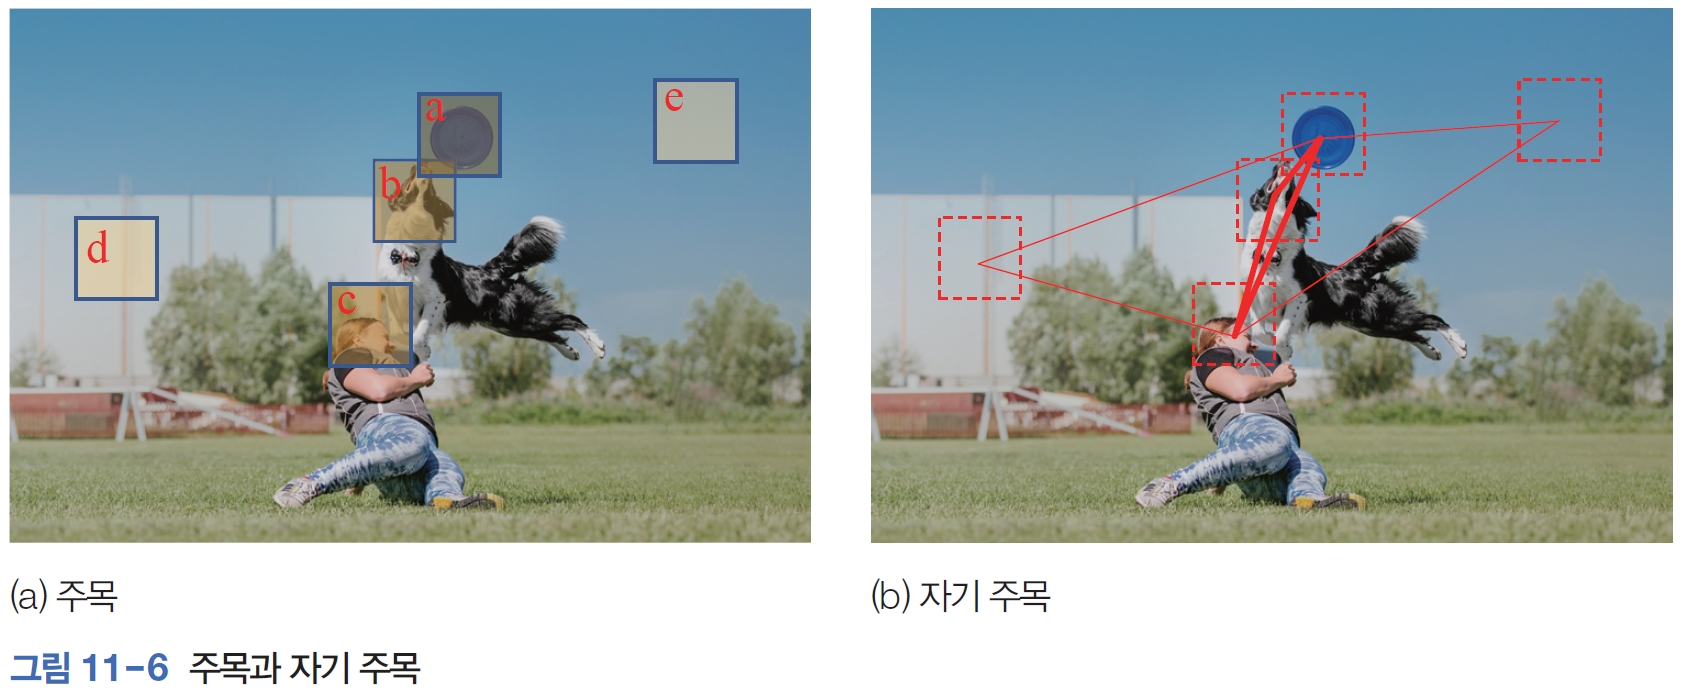

In [2]:
Image("그림 11-6.jpg", width=1080)

- note: 11-2 의 순환신경망에서의 주목도 의미있는 내용이나 보다 중요한 내용에 집중하기 위하여 이 강의에서는 생략하니 관심있는 학생을 읽어 보기 바란다.

## 3. 언어 모델 트랜스포머 (Language Transformer)

- 트랜스포머 구조가 처음 응용되어 주목받은 언어 모델을 이해를 하고 이를 ViT (비젼 트랜스포머)에 어떻게 응용되었는지 살펴 본다.
- 구글의 2027년 논문인 "Attention is all you need" 라는 제목의 논문으로 시작한다.


### 트랜스포머 모델의 구조 

- 본 수업에서는 개념적으로 만 설명

   - 좀더 상세한 설명은 해당 논문과 다음 자료를 참고
        - The Illustrated Transformer, https://jalammar.github.io/illustrated-transformer/
        - Youtube의 3blue1Brown https://youtu.be/wjZofJX0v4M?si=BeLprQJLJP1UiCTt
   - 계산예는 교재에도 포함
    
- 처음 제안된 트랜스포머 모델은  Encoder 블럭과 디코더 블럭의 두 단계로 구성되었다. (최근은 LLM (GPT)은 주로 Decoder 만 사용한다.)

   - 역사적으로 번역 작업을 목적으로 고안 되었으며, 인코더는 입력언어의 문장을 해석하는 용도로, 디코더는 목적 언어로 문장을 생성하는 용도로 사용되었다.

- 동일/유사한 형태의 입-출력 관계가 여러 계층으로도 구성된 계층구조 (기존의 네트워크와 유사).

- 입력과 출력의 단위는 토큰(단어)들 인데, vector embedding으로 동일한 길의의 벡터로 변환되어 사용된다.

  - 인코더는 입력이 동시에 입력된다 (RNN은 입력이 순차적으로 입력된다), 병렬처리가 필요하며, 속도가 빠르다.   
  - 디코더의 출력은 다시 디코더의 입력으로 들어가는데, 아직 출력되지 않은 출력은 mask를 통하여 무시하도록 한다.   

- 아래 단계의 계층의 벡터가 다음 단계의 계층으로 이동할때, attention 과정과 feed-forward 단계를 거친다.
   - 인코더에서 사용된 어텐션은 입력 자신의 문장안에서 사용되어 self-attnsion 이라고 부르고,
   - 디코더에서는 디코더 자체 입력간의 self-attention이후에 입력문에서와 cross-attention이 추가적으로 사용된다.
   - 직관적으로 설명하면 attention은 문맥을 사용하여 단어의 의미를 파학하는 것이라고 생각 할 수 있고 feed-forward 네트워크는 연상작용, 즉 관련된 단어를 끌어내는데 사용한다고 설명된다. 
        - 예) The dog cannot cross road becuase it is too narrow. 와  The cat cannot cross the road because it is too hugry에서 it이 의미하는 것을 찾는데 문맥이 사용된다.
        - 예) Micheal jorndan play 라고 했을때 다음 단어는 basketball이 나올수 잇는 것은. feed-forard 네트워크에서 마이클 조단 이라는 단어가 있으면 농구, 황제, 덩트슛과 같은 단어가 연관되어 질 수 있다.
        
- 내부적으로는 Add 와 norm이 있는데, 이것은 이전의 다른 네트워크에서도 사용되는 resisual 연결과 normaization으로 학습을 안정적이고 빠르게 해주는 역할을 한다. 


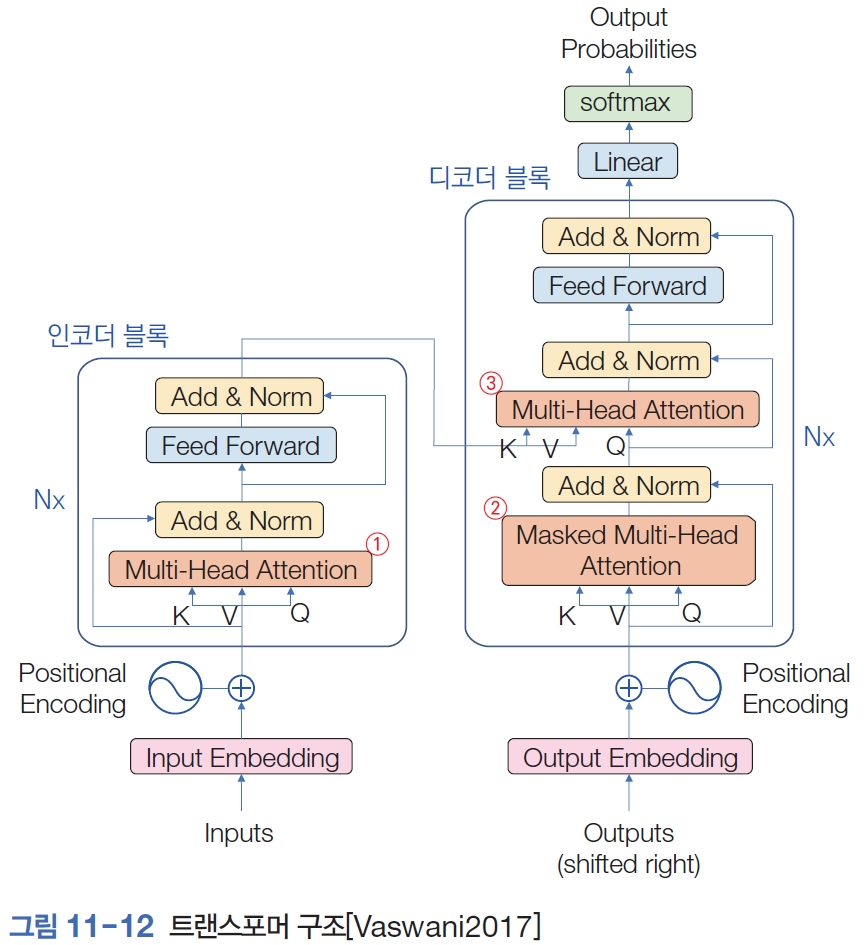

In [7]:
Image("그림 11-12.jpg", width=480)

### Attention  (is All we need)

- 현재 위치의 입력 토큰의 i vector에서 Q 파라메터 행렬을 곱하여 q벡터를 계산 (query)
- 나머지 토큰들의 i vector에서 K 파라메터 행렬을 곱하여 k vector들을 구한다. (key)
- 나머지 토큰들의 i vector에서 V 파라메터 행렬을 곱하여 k vector들을 구한다. (value)
- 현재 q vec 와 나머지 k vector를 inner product 하여 가중치 score 값을 구한다.
- 이 score 값을 가중치로 하여  vector 들을 가중 합을 하여  원래 i vector에 더한다.
- 이러한 구조를 header라고 부르고  여러개(처음 논문에는 6개)의 해더를 사용한다. 



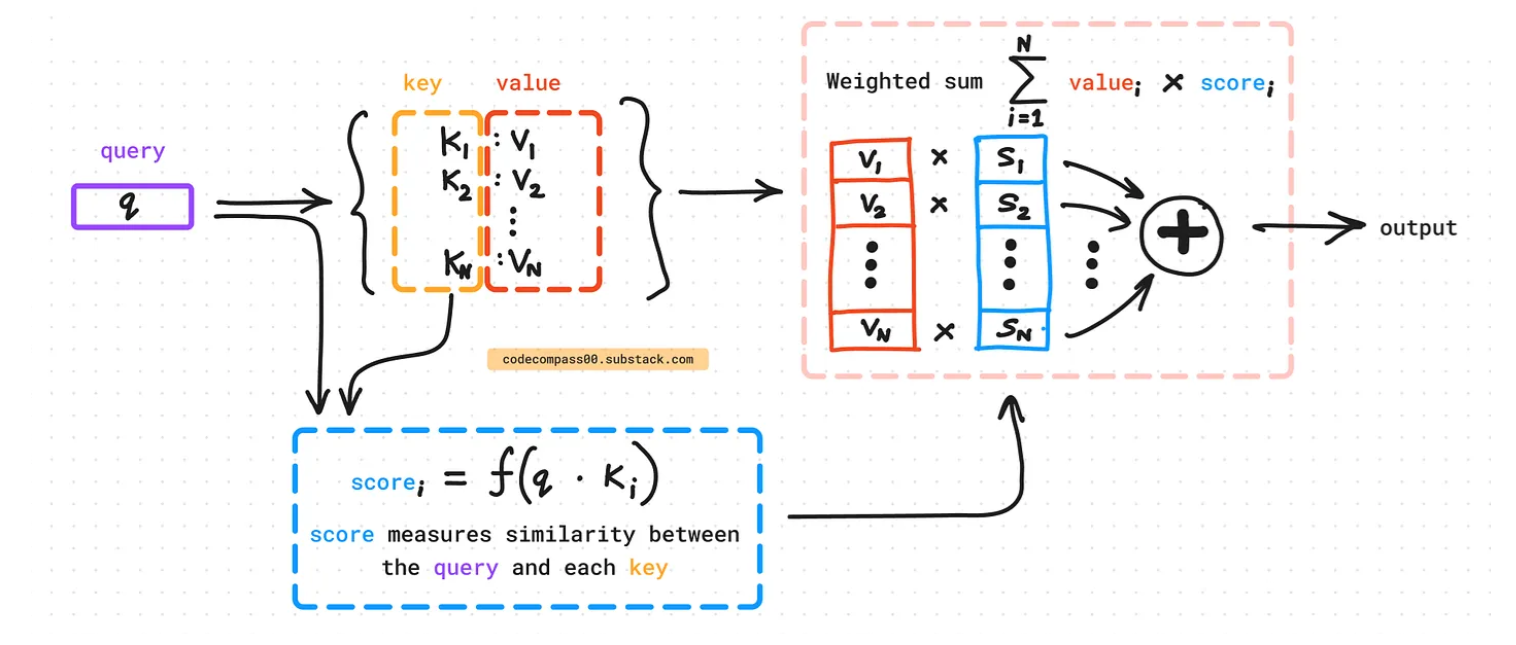

In [8]:
Image("attention1.png", width=1080)

### 예
 -  The animal didn't cross the street because it was too tired.
 -  The animal didn't cross the street because it was too wide.
 
  - Visualization tools
      - Transformer Explainer: https://poloclub.github.io/transformer-explainer/
      - Attention Visualizer : https://attention.streamlit.app/
  - 논문
      - "What Does BERT Look At?" (2019) Google Research 

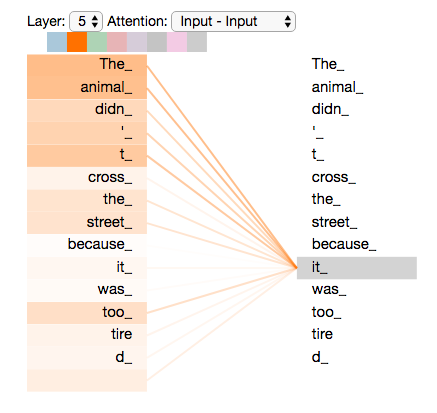

In [11]:
Image("attention2.png", width=480)

## 4. Vision Transformer 

- CNN 이후에 대표적인 방식 
   - CNN은 영상의 locality (가까운 화소가 현재화소의 해석에 중요한 역할을 하는 점을 이용)
   - 변수의 수가 작고 효과적이며, 공간적인 관련성이 CNN 필터 자체에 담겨 있음.
   
- 장점 
   - Transformer의 어텐션 기법을 사용하여 영상 전체의 연관성을 결합하는 특징
   - 언어모델과 통합이 유리 (multimodal)
   - 현재는 성능이 CNN을 앞서고 있음 
   
- 대표 모델들 
   - ViT (2021): 분류 모델 
   - DETR (2020): 검출
   - SETR (2021): 문할 
   - MOTR, Trackformer (2021): 추적 
   - Swin Transfomer (2021): 분류, 검출, 분할, 추적을 모두 지원
   

### 1) ViT (Vision Transformer)

- 입력/출력 구조
   - 원 Transformer는 text 입출력으로, 입력 출력이 모두 1차원 시퀀스
   - 영상은 2차원 구조를 갖음: 입력을 patch로 잘라 1차원적으로 정렬, 위치를 넣기 위하여 position 정보를 더해 줌. 
   - 분류 문제의 출력은 하나의 값 (scalar 또는 크기 1의 벡터) : Transformer의 encoder만 사용  

- 처리 과정

   - 이미지를 pxp 개의 겹치지 않는 패치로 나눔:   패치의 크기는 (h/p, w/p, 3)
   - 하나의 패치를 1차원 또는 2차원적으로 embedding 하여 1차원 벡터로 변환 (벡터의 크기 d_model)
   - 맨 마지막에 CLS분류용 토큰을 하나 추가하다. 
       - Transformer의 encoder는 기본적으로 n개의 입력이 들어가면 n개의 출력이 나오는 구조이므로, 최종 분류 출력용으로 하나의 공간을 추가로 만드는 방법을 사용.
   - 여기에 패치의 위치정보를 나타내는 벡터정보를 포함한다.
   - 이 결과를 Transformer의 encoder에 넣는다.
   - 마지막 단의 CLS 토큰의 출력 결과를 classifier 로 사용한다.
   

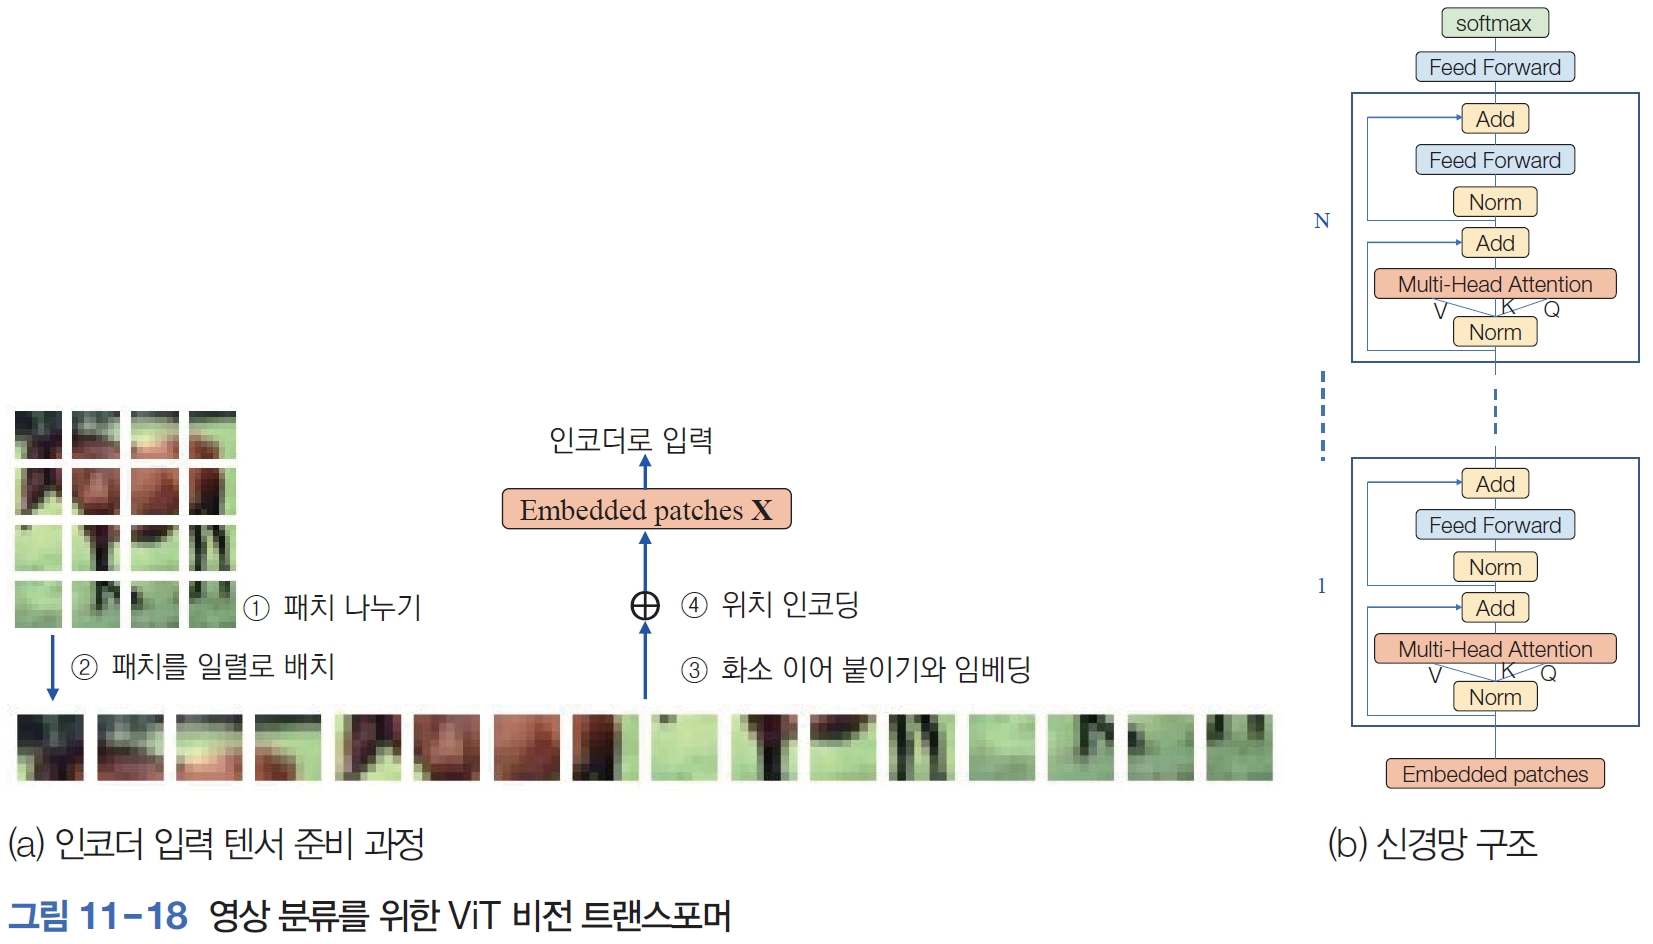

In [12]:
Image("그림 11-18.jpg", width=1080)

## ViT 실습
